# Un modelo de clasificación.

Para ejemplificar la aplicación de un modelo de clasificación se emplea la base pública “Titanic: Machine Learning from Disaster” del sitio web https://www.kaggle.com/, la cual es usada ampliamente por los usuarios de análisis de datos para probar diversas técnicas y algoritmos de predicción.

La base cuenta con información de los 2224 pasajeros y tripulación del transatlántico británico RSM Titanic, el cual se hundió el 15 de abril de 1912, donde fallecieron 1502 personas.

Dependiendo de las características de las personas como sex(sexo), Age(edad), Clase-socioeconómica entre otras, el objetivo es generar un modelo de clasificación para determinar cuáles personas sobreviven y cuáles fallecen en función de estas variables predictoras

# Preprocesamiento de datos

El preprocesamiento de los datos para que estén listo para su modelación incluye los siguientes pasos:

1. Importación de las bases.
2. Exploración preliminar de la información.
3. Tratamiento de datos faltantes.
4. Análisis univariado de la respuesta y análisis bivariado respecto a los predictores.
5. Ingeniería y transformación de variables.
6. Eliminación de algunas variables predictoras.
7. Análisis de datos atípicos.
8. Generación de conjunto de entrenamiento y validación


Veamos a continuación cómo se realizan estos pasos a los datos del titanic empleado diversas librerías de python.

## 1. Importación de las bases ##



Los datos se tienen que guarda en la carpeta de "Colab Notebooks".

Para poder acceder a los datos es necesario primero montar el drive en google colab, para lo cual se corre el siguiente código:

In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


Una vez hecha la conexión se busca importar la información. Para esto se usa la libreria de **pandas** la cual permite trabajar con marcos de datos. También se carga la libreria **numpy** que permite operar con arreglos.

In [2]:
#Se cargan las librerias pandas y numpy
import pandas as pd
import numpy as np

Usamos la función `read_csv()` del módulo pandas para leer un archivo `csv` y convertirlo a dataframe.



In [3]:
#Buscamos la dirección de lo datos
datos_titanic="/content/drive/MyDrive/Colab Notebooks/GitHub/Titanic: Machine Learning from Disaster/datos_titanic.csv"
df_titanic=pd.read_csv(datos_titanic)

Podemos ver en dataframe si ejecutamos su nombre

In [4]:
df_titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 2. Exploración preliminar de la información

Una vez cargados lo datos es necesario hacer una ***inspección inicial*** para conocer ***características de la base*** como por ejemplo el **número de columnas**, **tipos de campos**, **registros con datos faltantes**, y obtener algunos **estadísticos básicos**  para de las *variables continuas* como **media, mediana, moda, mínimo, máximo,** y para *variables discretas:* **frecuencias relativas**.

Esta información será un **punto de partida** para el tratamiento posterior, ya que nos dará un panorama general de la estructura de los datos.




Podemos ver cuantas filas y columnas hay con el atributo `shape`

In [5]:
df_titanic.shape

(891, 12)

Tenemos un dataframe con 891 filas y 12 columnas.

También podemos conocer el nombre de las columnas con el atributo `columns`

In [6]:
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

La información anterior se puede obtener con el método `info()`

In [7]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Podemos obtener estadísticas descriptivas con el método `describe()` que incluye un resumen de tendencia central

In [8]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Podemos hacer una exploración de las columnas tipo *object*

In [9]:
#Seleccionamos las columnas tipo "object"
df_columnas_object = df_titanic.select_dtypes(include='object')
df_columnas_object.head()


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


Vemos cuantos valores únicos hay en cada una de esas columnas

In [10]:
#Obtener el número de valores únicos para cada columna tipo object
df_resumen = df_columnas_object.nunique().reset_index()
df_resumen.columns = ['Variable', 'Valores únicos']

#Mostrar el resumen
print(df_resumen)

   Variable  Valores únicos
0      Name             891
1       Sex               2
2    Ticket             681
3     Cabin             147
4  Embarked               3


Proseguimos a identificar si existen algunas columnas que realmente no den información o ayuden a la generación de modelos de predicción. Si existen estas deben ser removidas antes de proseguir con el analis de datos, así nos evitamos análisis y computo inecesario.
Estas variables son no informativas, generalmente son variables las cuales resultan evidentes su relación con la variable de respuesta.

Usualmente existen llaves para el manejo de bases de datos o algún identificador de los registros de la base.

En este caso la **llave** o identificador es la columna *PassengerId* en el dataframe *df_titanic* podemos ver que es simplemente una numeración de las filas. Procedemos a quitarla con el método `drop()`.

In [11]:
print(df_titanic.shape)
df_titanic.drop(['PassengerId'], axis = 'columns', inplace=True)
print(df_titanic.shape)

(891, 12)
(891, 11)


## 3. Ingeniería de variables

La ingeniería de variables consiste en la generación de nuevos predictores, esto para mejorar el poder de predicción del modelo. Usualmente se atribuye al entendimiento del problema y no es una técnica matemática o estadística.

Vamos a hacer un ejemplo de este tipo de ingeniería.  En nuestra base de datos tenemos títulos de tratamiento, es decir, Mr. es un hombre adulto, Miss  cualquier mujer no casada, etc

In [12]:
#Extraemos los títulos de 'Name' y agregamos una columna 'Title' con ellos
df_titanic['Title'] = df_titanic['Name'].str.extract(r',\s*([^\.]*)\s*\.',expand=False)

#Quitamos espacios antes y despues
df_titanic['Title'] = df_titanic['Title'].str.strip()

#Mostramos los casos
conteo_title = df_titanic['Title'].value_counts()
print(conteo_title)

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


Como vemos, tenemos demasiados niveles, vamos a reducirlos a solo cinco niveles más comunes.

In [13]:
#Función para generar cinco niveles
def mapear_titles(title):
  if title in ['Mr', 'Mrs', 'Miss', 'Master']:
    return title
  else:
    return 'Rare Title'

#Aplicamos la función
df_titanic['Title'] = df_titanic['Title'].apply(mapear_titles)

#Mostramos el resultado
print('Variable con cinco niveles')
print(df_titanic['Title'].value_counts())

Variable con cinco niveles
Title
Mr            517
Miss          182
Mrs           125
Master         40
Rare Title     27
Name: count, dtype: int64


Hemos usado la variable *Name* para crear otra llamada *Title* que tiene cinco niveles. Ahora es recomendable eliminar la variable *Name* pues una **variable categórica nominal** que posee tantos niveles como pasajeros, parecido a una **llave**.

In [14]:
print(df_titanic.shape)
df_titanic.drop('Name', axis='columns', inplace=True)
df_titanic.shape

(891, 12)


(891, 11)

In [15]:
df_titanic.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked', 'Title'],
      dtype='object')

Otra variable que podemos estudiar es *Ticket* varios pasajeros comparten el número de ticket porque están juntos. Así podemos extraer esta información y crear una nueva variable que podemos llamar *Companions*, el numero de acopañantes.

In [16]:
#Crea la columna 'Companions'
df_titanic['Companions'] = df_titanic.groupby('Ticket')['Ticket'].transform('count')

In [17]:
#Mostramos la distribución del numero de acompañantes
df_titanic['Companions'].value_counts()

,count
Companions,
1,547
2,188
3,63
4,44
7,21
6,18
5,10


Ahora es recomdable eliminar la columna *Ticket* una vez creada la variable *Companions*, pues esta tiene muchos menos niveles.

In [18]:
print(df_titanic.shape)
df_titanic.drop(['Ticket'], axis='columns', inplace=True)
df_titanic.shape

(891, 12)


(891, 11)

In [19]:
df_titanic.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked', 'Title', 'Companions'],
      dtype='object')

## 4. Tratamiento de datos faltantes.

Cuando se está trabajando con una base de datos es importante revisar si algunas variables explicativas tienen datos faltantes, pues esto puede afectar la aplicación de los modelos estadísticos de aprendizaje.

(1) Si la cantidad de información es grande, y el **porcentaje de registros con datos faltantes es pequeño** (<5\%), se puede optar por quitarlos y trabajar con el subconjunto de datos completos.

(2) Sin embargo, a veces la base de datos no es tan extensa o se quiere aprovechar la información que aportan las demás variables por lo que en este caso se puede proceder a **imputar** los datos faltantes, esto es, ***rellenar los registros de los campos vacíos***.

In [20]:
#Contamos el numero de valores que estan vacios
df_titanic.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2
Title,0


In [21]:
#Si lo divido entre el número total de entradas obtengo la proporción de faltantes
df_titanic.isnull().sum()/df_titanic.shape[0]

,0
Survived,0.000000
Pclass,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Fare,0.000000
Cabin,0.771044
Embarked,0.002245
Title,0.000000


En el caso de la variable Cabin, se tiene una cantidad muy alta de valores ausentes 77%. Se considera que imputar estos valores introducirá más ruido al modelo que lo que puede ser útil, por lo que se decide quitar esta variable de la base.

In [22]:
print(df_titanic.shape)
df_titanic.drop(['Cabin'], axis = 'columns', inplace=True)
df_titanic.shape

(891, 11)


(891, 10)

Vamos a imputar los datos faltantes con el algoritmo ```miceforest``` con LightGBM (Light Gradient Boosting Machine)



In [23]:
!pip install miceforest lightgbm

In [24]:
#Importamos miceforest
import miceforest as mf

In [25]:
#Se crea una función para crear variables categoricas
def object_to_category(df):
    variables_obj = df.select_dtypes(include=['object']).columns
    df[variables_obj] = df[variables_obj].astype('category')
    return df

In [26]:
#Se aplica la función
df_titanic = object_to_category(df_titanic)

In [27]:
#Se crea el kernel de imputación
kernel = mf.ImputationKernel(
    data=df_titanic,
    random_state=42
)

In [28]:
kernel.mice(5)  # número de iteraciones

In [29]:
df_titanic_imp = kernel.complete_data()

In [30]:
#Miramos los valores faltantes
df_titanic_imp.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Title,0
Companions,0


## Análisis de la respuesta y su relación con cada predictor

En este caso la respuesta es binaria podemoa hacer una tabla de frecuencias así como una gráfica de barras con las proporciones personas que sobrevivieron y las que no.

In [31]:
#Se genera un objeto tipo panda-series
proporciones_survived = df_titanic_imp['Survived'].value_counts(normalize=True)

#Se crea un dataframe
pd.DataFrame(proporciones_survived)

,proportion
Survived,
0,0.616162
1,0.383838


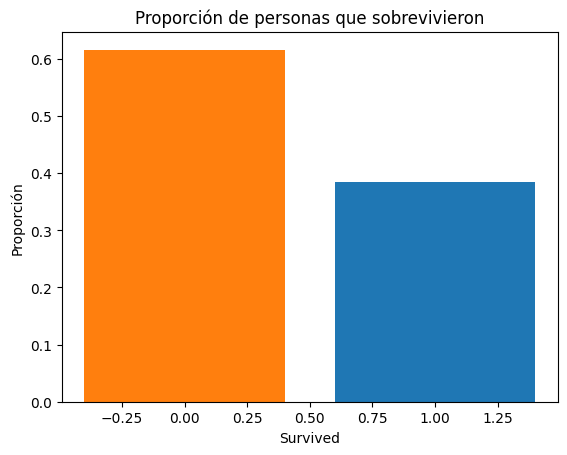

In [32]:
#Cargamos el paquete matplotlib
import matplotlib.pyplot as plt

#Creamos la gráfica de barras
plt.bar(x=proporciones_survived.index,
        height=proporciones_survived.values,
        color=['tab:orange','tab:blue'])
#Etiquetas de la gráfica
plt.xlabel('Survived')
plt.ylabel('Proporción')
plt.title('Proporción de personas que sobrevivieron')
#Mostramos la gráfica
plt.show()

Como la variable de respuesta es binaria se puede analizar la relación con otras variables categóricas, graficando la proporcion de los niveles de la variable *Survived* para cada nivel de la variable predictora.

Analizamos la variable predictora *Sex* con *Survived*

In [33]:
df_survived_vs_sex = pd.crosstab(df_titanic_imp['Sex'],df_titanic_imp['Survived'],normalize='index')*100
print(df_survived_vs_sex)

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


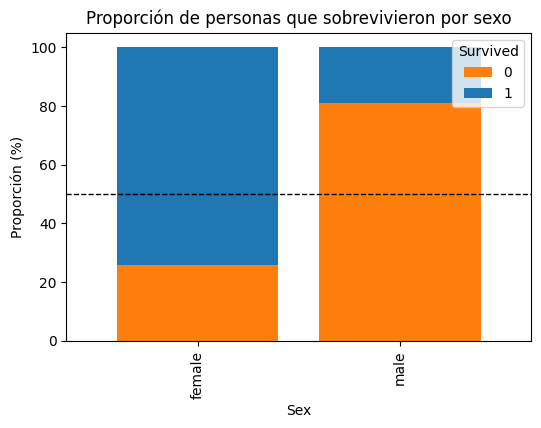

In [34]:
from matplotlib import lines
# Grafica de la barra apilada
ax = df_survived_vs_sex.plot(kind='bar', stacked=True,
                             color=['tab:orange','tab:blue'],
                             width=0.8,figsize=(6,4))
#Etiquetas
plt.xlabel('Sex')
plt.ylabel('Proporción (%)')
plt.title('Proporción de personas que sobrevivieron por sexo')
plt.legend(title='Survived', loc='upper right')

#Línea que divide en dos barras
ax.axhline(50, color='black', linestyle='--', linewidth=1)

#Mostramos la gŕafica
plt.show()

Resulta envidente que sobrevivieron más mujeres que hombres. Ser mujer aumenta las probabilidades de sobrevivir en el Titanic.

De manera símilar se hace una gráfica para la variable *Survived* vs *Title*.

Se  muestra la gráfica:


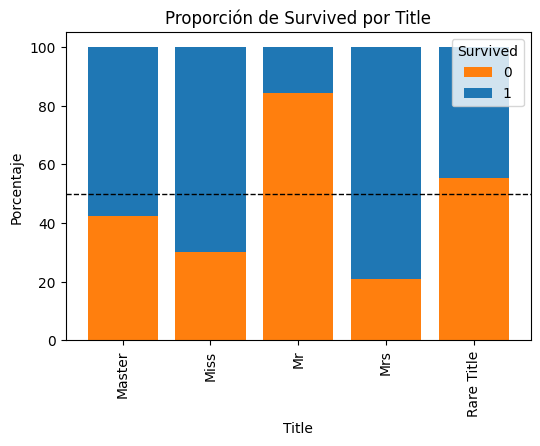

In [35]:
# Crear un DataFrame resumen con la proporción de '0' y '1'
# para cada nivel de Title
df_Survived_vs_Title = pd.crosstab(df_titanic_imp['Title'],
                                   df_titanic_imp['Survived'],
                                   normalize='index') * 100
# Graficar la barra apilada
ax = df_Survived_vs_Title.plot(kind='bar', stacked=True,
                               color=['tab:orange', 'tab:blue'],
                               width=0.8, figsize=(6, 4))
# Añadir etiquetas y título
plt.xlabel('Title')
plt.ylabel('Porcentaje')
plt.title('Proporción de Survived por Title')
plt.legend(title='Survived', loc='upper right')

# Añadir la línea que divide en dos barras
ax.axhline(50, color='black', linestyle='--', linewidth=1)

# Mostrar la gráfica
print("Se  muestra la gráfica:")
plt.show()

De la gráfica anterior nos damos cuenta que los niños y mujeres tienen proporciones de supervivencia mayores al 50%.

Ahora vemos que pasa para *Survived* vs *Embarked*

Survived          0          1
Embarked                      
C         44.117647  55.882353
Q         61.038961  38.961039
S         66.304348  33.695652
Se  muestra la gráfica:


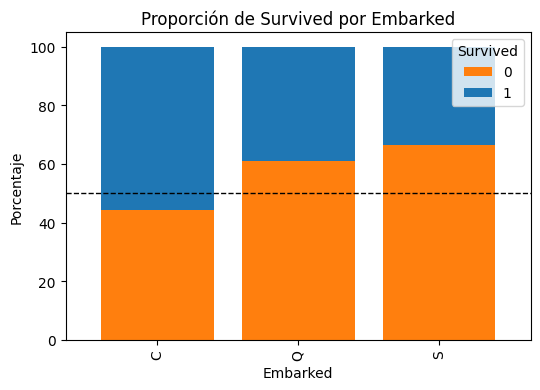

In [36]:
# Crear un DataFrame resumen con la proporción de '0' y '1'
# para cada nivel de Embarked
df_Survived_vs_Embarked = pd.crosstab(df_titanic_imp['Embarked'],
                                   df_titanic_imp['Survived'],
                                   normalize='index') * 100
print(df_Survived_vs_Embarked)


# Graficar la barra apilada
ax = df_Survived_vs_Embarked.plot(kind='bar', stacked=True,
                               color=['tab:orange', 'tab:blue'],
                               width=0.8, figsize=(6, 4))

# Añadir etiquetas y título
plt.xlabel('Embarked')
plt.ylabel('Porcentaje')
plt.title('Proporción de Survived por Embarked')
plt.legend(title='Survived', loc='upper right')

# Añadir la línea que divide en dos barras
ax.axhline(50, color='black', linestyle='--', linewidth=1)

# Mostrar la gráfica
print("Se  muestra la gráfica:")
plt.show()

En este caso observamos que hay más posibilidades de sobrevivir si el pasajero se embarcó en S=Southampton

Analizando la supervivencia con las clases, esto es *Survived* vs *Pclass*

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253
Se  muestra la gráfica:


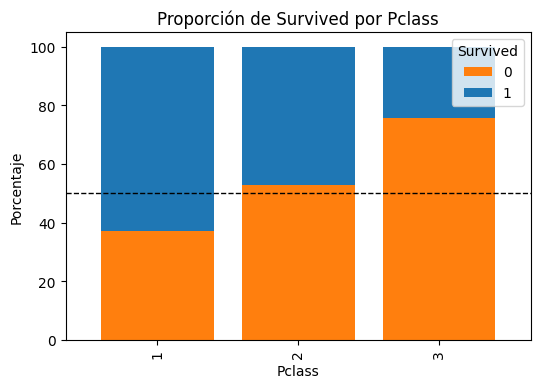

In [37]:
# Crear un DataFrame resumen con la proporción de '0' y '1'
# para cada nivel de Embarked
df_Survived_vs_Pclass = pd.crosstab(df_titanic_imp['Pclass'],
                                   df_titanic_imp['Survived'],
                                   normalize='index') * 100
print(df_Survived_vs_Pclass)


# Graficar la barra apilada
ax = df_Survived_vs_Pclass.plot(kind='bar', stacked=True,
                               color=['tab:orange', 'tab:blue'],
                               width=0.8, figsize=(6, 4))

# Añadir etiquetas y título
plt.xlabel('Pclass')
plt.ylabel('Porcentaje')
plt.title('Proporción de Survived por Pclass')
plt.legend(title='Survived', loc='upper right')

# Añadir la línea que divide en dos barras
ax.axhline(50, color='black', linestyle='--', linewidth=1)

# Mostrar la gráfica
print("Se  muestra la gráfica:")
plt.show()

Finalmente se hace un último analisis con la edad *Age*, en este caso la edad es en principio una variable continua, se puede discretizar para generar cierto niveles.

Survived              0          1
Age_Category                      
(-1.0, 19.0]  52.631579  47.368421
(19.0, 25.0]  69.714286  30.285714
(25.0, 31.0]  64.556962  35.443038
(31.0, 41.0]  58.045977  41.954023
(41.0, 80.0]  65.142857  34.857143
Se  muestra la gráfica:


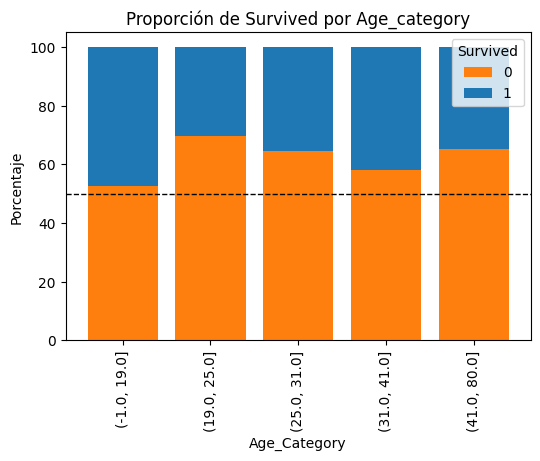

In [38]:
#'Age' es la columna que se desea discretizar
num_bins = 5  # Número de intervalos deseados

#Hacer las particiones con la función qcut()
bins = pd.qcut(df_titanic_imp['Age'], q=num_bins,
               precision=0, duplicates='drop')

#Se transforma el objeto pandas Series a tipo category para extraer las etiquetas
#en las que se discretizó la variable numérica
bins_categorical = bins.astype('category')
Age_categories = bins_categorical.cat.categories

#Se hace la partición de las 5 categorías y se guarda en la variable 'Age_Category'
df_titanic_imp['Age_Category'] = pd.qcut(df_titanic_imp['Age'],
                                            q=num_bins, labels=Age_categories,
                                            precision=0, duplicates='drop')

df_Survived_vs_Age = pd.crosstab(df_titanic_imp['Age_Category'],
                                 df_titanic_imp['Survived'],
                                 normalize='index') * 100
print(df_Survived_vs_Age)

# Graficar la barra apilada
ax = df_Survived_vs_Age.plot(kind='bar',
                             stacked=True,
                             color=['tab:orange', 'tab:blue'],
                             width=0.8, figsize=(6, 4))

# Añadir etiquetas y título
plt.xlabel('Age_Category')
plt.ylabel('Porcentaje')
plt.title('Proporción de Survived por Age_category')
plt.legend(title='Survived', loc='upper right')

# Añadir la línea que divide en dos barras
ax.axhline(50, color='black', linestyle='--', linewidth=1)

# Mostrar la gráfica
print("Se  muestra la gráfica:")
plt.show()

A medida que aumenta la edad también aumenta la posibilidad de fallecer después de la catástrofe. Baja ligeramente edads mayores de 31 pero menores de 40.

In [39]:
#Se eliminan todas las variables categóricas que se discretizaron
#Sólo se usaron con fines exploratorios

df_titanic_imp.drop(['Age_Category'], axis = 'columns', inplace=True)

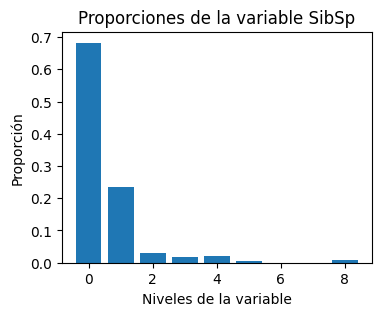

In [40]:
#Se genera un objeto tipo pandas-series
Proporciones_SibSp = df_titanic_imp['SibSp'].value_counts(normalize=True)

#Se crea un marco de datos Pandas a partir del objeto pandas-series
pd.DataFrame(Proporciones_SibSp)

#Tamaño de la imagen
plt.figure(figsize=(4,3))

# Crear una gráfica de barras con función plt.bar()
plt.bar(x=Proporciones_SibSp.index,
        height=Proporciones_SibSp.values)

# Configurar etiquetas y título
plt.xlabel('Niveles de la variable')
plt.ylabel('Proporción')
plt.title('Proporciones de la variable SibSp')


# Mostrar la gráfica
plt.show()

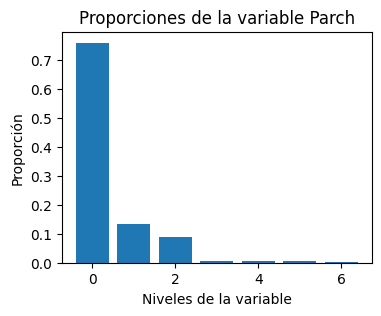

In [41]:
#Se genera un objeto tipo pandas-series
Proporciones_Parch = df_titanic_imp['Parch'].value_counts(normalize=True)

#Se crea un marco de datos Pandas a partir del objeto pandas-series
pd.DataFrame(Proporciones_Parch)

#Tamaño de la imagen
plt.figure(figsize=(4,3))

# Crear una gráfica de barras con función plt.bar()
plt.bar(x=Proporciones_Parch.index,
        height=Proporciones_Parch.values)

# Configurar etiquetas y título
plt.xlabel('Niveles de la variable')
plt.ylabel('Proporción')
plt.title('Proporciones de la variable Parch')

# Mostrar la gráfica
plt.show()

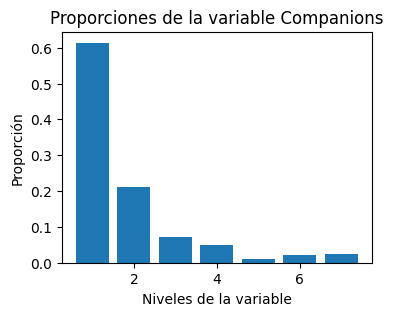

In [42]:
#Se genera un objeto tipo pandas-series
Proporciones_Companions = df_titanic_imp['Companions'].value_counts(normalize=True)

#Se crea un marco de datos Pandas a partir del objeto pandas-series
pd.DataFrame(Proporciones_Companions)

#Tamaño de la imagen
plt.figure(figsize=(4,3))

# Crear una gráfica de barras con función plt.bar()
plt.bar(x=Proporciones_Companions.index,
        height=Proporciones_Companions.values)

# Configurar etiquetas y título
plt.xlabel('Niveles de la variable')
plt.ylabel('Proporción')
plt.title('Proporciones de la variable Companions')

# Mostrar la gráfica
plt.show()

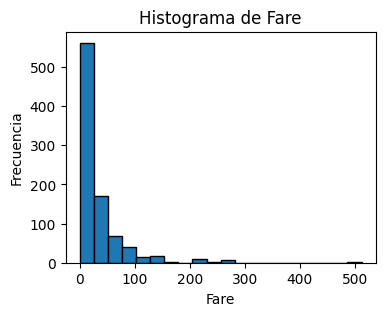

In [43]:
# Histograma de Fare
plt.figure(figsize=(4,3))
plt.hist(df_titanic_imp['Fare'], bins=20, color='tab:blue', edgecolor='black')

# Personalizar el gráfico
plt.title('Histograma de Fare')
plt.xlabel('Fare')
plt.ylabel('Frecuencia')

# Mostrar el histograma
plt.show()

## Análisis de datos atípicos

Son observaciones de algunas variables que poseen un comportamiento fuera de lo común. Metodos con fundamento estadistico para tratar datos atípicos son **Tukey** y **Hampel**.

Para darle un tratamiento a los datos atípicos podemos usar el paquete `Feature-engine`.

In [44]:
#Se instala Feature-engine
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.4 MB/s eta 0:00:00


In [45]:
#Se importa la clase Winsorizer
from feature_engine.outliers import Winsorizer

#Se initializa el objeto que va a limitar los valores atípicos
capper = Winsorizer(capping_method='iqr',
                    tail='right',
                    fold=3,
                    variables=['Age', 'Fare'])

#Se hace el ajuste sobre los datos
capper.fit(df_titanic_imp)

Winsorizer(capping_method='iqr', fold=3, variables=['Age', 'Fare'])

In [46]:
#Imprimir los límites en un diccionario
print(capper.right_tail_caps_)

{'Age': 92.0, 'Fare': 100.2688}


In [47]:
#Transformar los datos
df_titanic_imp_outlier = capper.transform(df_titanic_imp)

## Eliminación de algunas variables predictoras

La razón de eliminar algunas variables predictoras tiene que ver con la reducción en complejidad y el tiempo computacional del modelo al ajustarlo con menos variables.

Se van a ver dos situaciones donde resulta conveniente eliminar variables:

1. Variables de varianza cero o casi cero

2. Varibles altamente correlacionadas linealmente.

Para eliminar las variables constantes o casi constantes podemos usar `DropConstantFeatures`

In [48]:
#Se carga la clase
from feature_engine.selection import DropConstantFeatures

#Se inicializa el objeto
#Se usa una tolerancia de 0.98 para eliminar
#las variables que muestren el mismo valor en el 98% de las observaciones.
dcf = DropConstantFeatures(tol=0.98)

#Se hace el ajuste sobre los datos para buscar las variables a eliminar
dcf.fit(df_titanic_imp_outlier)

DropConstantFeatures(tol=0.98)

In [49]:
#Para ver cuales son las variables a eliminar se puede imprimir el tributo
# features_to_drop_

dcf.features_to_drop_

[]

En este caso ninguna variable tiene datos que se repiten en el 98% de sus observaciones

In [50]:
df_titanic_imp_outlier_elimi = dcf.transform(df_titanic_imp_outlier)

La otra forma de poder eliminar alguna variable es si esta muy correlacionada con otra, para eso podemos hacer una matriz de correlacion muestral.

In [51]:
#Se importa la clase find_or_check_numerical_variables para
#que regrese una lista con las variables numéricas
from feature_engine.variable_handling import find_numerical_variables

#Se crea una lista de variables numéricas
var_num = find_numerical_variables(df_titanic_imp_outlier_elimi)
print(var_num)

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Companions']


In [52]:
# Aplica el método corr() al objeto pandas dataframe
# para obtener la matriz de correlaciones
corr_matrix=df_titanic_imp_outlier_elimi[var_num].corr()
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare,Companions
Survived,1.000000,-0.338481,-0.082451,-0.035322,0.081629,0.318097,0.038247
Pclass,-0.338481,1.000000,-0.393878,0.083081,0.018443,-0.702985,-0.002633
Age,-0.082451,-0.393878,1.000000,-0.313929,-0.208464,0.123320,-0.273199
SibSp,-0.035322,0.083081,-0.313929,1.000000,0.414838,0.269818,0.661622
Parch,0.081629,0.018443,-0.208464,0.414838,1.000000,0.263486,0.593076
Fare,0.318097,-0.702985,0.123320,0.269818,0.263486,1.000000,0.459298
Companions,0.038247,-0.002633,-0.273199,0.661622,0.593076,0.459298,1.000000


Podemos crear un mapa de calor con `seaborn` para vizulaizar mejor estas correlaciones

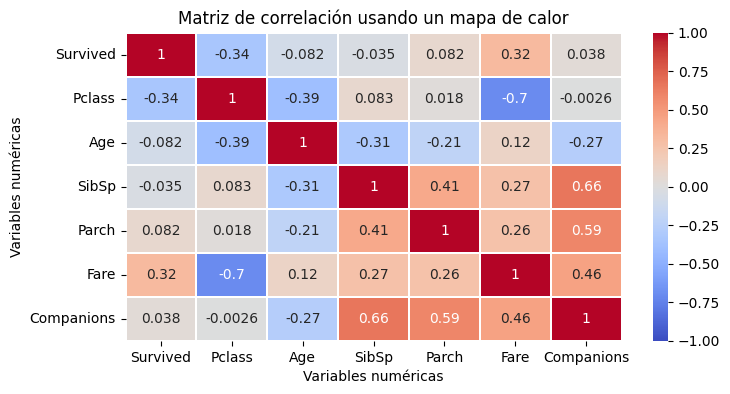

In [53]:
#Importamos el paquete seaborn
import seaborn as sns

#Graficamos la matriz de correlaciones
plt.figure(figsize=(8,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            linewidths=0.2, vmin=-1, vmax=1)
plt.xlabel('Variables numéricas')
plt.ylabel('Variables numéricas')
plt.title('Matriz de correlación usando un mapa de calor')
plt.show()

A continuación creamos una matriz entre las variables con la respuesta.

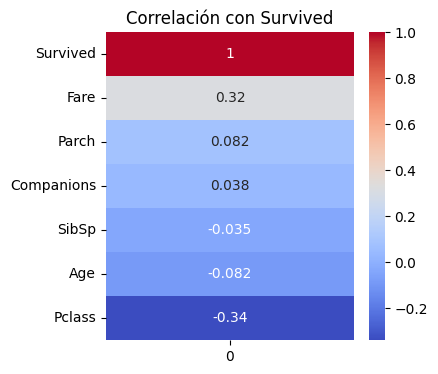

In [54]:
# Crea una matriz de correlación con la respuesta
target = df_titanic_imp_outlier_elimi['Survived']
corr_with_target = df_titanic_imp_outlier_elimi[var_num].corrwith(target)

# Ordenar de forma descendente
corr_with_target = corr_with_target.sort_values(ascending=False)

# Mapa de calor
plt.figure(figsize=(4, 4))
sns.heatmap(corr_with_target.to_frame(), cmap='coolwarm', annot=True)
plt.title('Correlación con Survived')
plt.show()

En caso de obntener colinealidad se puede eliminar aquellas que tengan menos correlacion con la respuesta y en ese caso podemos hacer uso de `SmartCorrelatedSelection`

## Transformación de variables continuas y categóricas

Para realizar ciertas transformaciones de variables continuas o categóricas se puede emplear el paquete `feature-engine`. La recomendación es no discretizar variables continuas pues se suele perder poder predictivo.

En el caso de variables categóricas, algunos algoritmos no puede procesar texto por lo que hay que trasformar variables a valores numéricos.

In [55]:
df_titanic_imp_outlier_elimi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Embarked    891 non-null    category
 8   Title       891 non-null    category
 9   Companions  891 non-null    int64   
dtypes: category(3), float64(2), int64(5)
memory usage: 51.9 KB


In [56]:
#Se carga la clase OneHotEncoder
from feature_engine.encoding import OneHotEncoder

#Se inicializa el objeto con codificación
#de celda de referencia
encoder = OneHotEncoder(
    drop_last=True,
    variables=['Sex','Title', 'Embarked'],
    ignore_format=True)

# Realizar la codificación
encoder.fit(df_titanic_imp_outlier_elimi)

OneHotEncoder(drop_last=True, ignore_format=True,
              variables=['Sex', 'Title', 'Embarked'])

In [57]:
#Para revisar las categorías transformadas se puede observar
#el objeto encoder.encoder_dict_ que es un objeto tipo diccionario:
encoder.encoder_dict_

{'Sex': ['male'],
 'Title': ['Mr', 'Mrs', 'Miss', 'Master'],
 'Embarked': ['S', 'C']}

In [58]:
#Si quisieramos cambiar los elementos que generan los 0 y 1
#se puede modificar directamente el encoder.encoder_dict_
encoder.encoder_dict_ = {'Sex': ['female'],
 'Title': ['Mr', 'Mrs', 'Miss', 'Rare'],
 'Embarked': ['S', 'C']}
encoder.encoder_dict_

{'Sex': ['female'],
 'Title': ['Mr', 'Mrs', 'Miss', 'Rare'],
 'Embarked': ['S', 'C']}

In [59]:
#Se inicializa el objeto con codificación
#de "one-hot"
encoder = OneHotEncoder(
    drop_last=False,
    variables=['Sex','Title', 'Embarked'],
    ignore_format=True)

# Realizar la codificación
encoder.fit(df_titanic_imp_outlier_elimi)

#Para revisar las categorías transformadas se puede observar
#el objeto encoder.encoder_dict_ que es un objeto tipo diccionario:
encoder.encoder_dict_

{'Sex': ['male', 'female'],
 'Title': ['Mr', 'Mrs', 'Miss', 'Master', 'Rare Title'],
 'Embarked': ['S', 'C', 'Q']}

In [60]:
#Se crea un nuevo marco de datos
df_titanic_imp_outlier_elimination_tranf = encoder.transform(df_titanic_imp_outlier_elimi)

print(df_titanic_imp_outlier_elimination_tranf.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Companions  Sex_male  \
0         0       3  22.0      1      0   7.2500           1         1   
1         1       1  38.0      1      0  71.2833           1         0   
2         1       3  26.0      0      0   7.9250           1         0   
3         1       1  35.0      1      0  53.1000           2         0   
4         0       3  35.0      0      0   8.0500           1         1   

   Sex_female  Title_Mr  Title_Mrs  Title_Miss  Title_Master  \
0           0         1          0           0             0   
1           1         0          1           0             0   
2           1         0          0           1             0   
3           1         0          1           0             0   
4           0         1          0           0             0   

   Title_Rare Title  Embarked_S  Embarked_C  Embarked_Q  
0                 0           1           0           0  
1                 0           0           1           

La única variable original propiamente dicho es la variable de Pclass que tienen 3 niveles: 1era, 2da y 3era clase. Se puede codificar como variable original para que esté representada por números que empiecen por el 0 para 3era clase, 1 para 2da clase y 2 para 3era clase.

Si se quiere hacer una codificación para variables ordinales en general, se tiene que hacer lo siguiente:

In [61]:
#Se carga la clase OrdinalEncoder
from feature_engine.encoding import OrdinalEncoder

#Se crea un objeto de la clase
od = OrdinalEncoder(encoding_method='arbitrary',
                    variables=['Pclass'],
                    ignore_format=True)

# Realizar la codificación
od.fit(df_titanic_imp_outlier_elimination_tranf)

#Diccionario con la codificación
od.encoder_dict_

{'Pclass': {np.int64(3): 0, np.int64(1): 1, np.int64(2): 2}}

In [62]:
# Cambio de los niveles para asignar el propuesto:
# 0 para 3era clase, 1 para 2da clase y 2 para 3era clase.
od.encoder_dict_ = {'Pclass': {3: 0, 2: 1, 1: 2}}

In [63]:
#Se crea un nuevo marco de datos
df_titanic_imp_outlier_elimination_tranf2 = od.transform(df_titanic_imp_outlier_elimination_tranf)

print(df_titanic_imp_outlier_elimination_tranf2.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Companions  Sex_male  \
0         0       0  22.0      1      0   7.2500           1         1   
1         1       2  38.0      1      0  71.2833           1         0   
2         1       0  26.0      0      0   7.9250           1         0   
3         1       2  35.0      1      0  53.1000           2         0   
4         0       0  35.0      0      0   8.0500           1         1   

   Sex_female  Title_Mr  Title_Mrs  Title_Miss  Title_Master  \
0           0         1          0           0             0   
1           1         0          1           0             0   
2           1         0          0           1             0   
3           1         0          1           0             0   
4           0         1          0           0             0   

   Title_Rare Title  Embarked_S  Embarked_C  Embarked_Q  
0                 0           1           0           0  
1                 0           0           1           

En el caso de que se tenga que implementar un modelo de regularización, toda las variables deben tener la misma escala. Por lo que se transforman tanto las one-hot como las continuas

In [64]:
#Se importa la clase StandardScaler
from sklearn.preprocessing import StandardScaler
from feature_engine.wrappers import SklearnTransformerWrapper

#Extraemos los nombres de las columnas en una lista
#Quito la variable de respuesta, que es la primera de la lista( por eso [1:])
nombres_predictores = df_titanic_imp_outlier_elimination_tranf2.columns.tolist()[1:]

# Se hace la envoltura de StandardScaler dentro de SklearnTransformerWrapper
#Considero que la transformación solo se aplica a los predictores
scaler = SklearnTransformerWrapper(transformer = StandardScaler() ,
                                   variables=nombres_predictores)

# Ajuste wrapper + StandardScaler
scaler.fit(df_titanic_imp_outlier_elimination_tranf2)

# Transformación de los datos
df_titanic_imp_outlier_elimination_tranf3 = scaler.transform(df_titanic_imp_outlier_elimination_tranf2)
df_titanic_imp_outlier_elimination_tranf3

,Survived,Pclass,Age,SibSp,Parch,Fare,Companions,Sex_male,Sex_female,Title_Mr,Title_Mrs,Title_Miss,Title_Master,Title_Rare Title,Embarked_S,Embarked_C,Embarked_Q
0,0,-0.827377,-0.525306,0.432793,-0.473674,-0.724384,-0.579162,0.737695,-0.737695,0.850532,-0.403962,-0.506655,-0.216803,-0.176777,0.619306,-0.485576,-0.307562
1,1,1.566107,0.573290,0.432793,-0.473674,1.619088,-0.579162,-1.355574,1.355574,-1.175735,2.475480,-0.506655,-0.216803,-0.176777,-1.614710,2.059412,-0.307562
2,1,-0.827377,-0.250657,-0.474545,-0.473674,-0.699681,-0.579162,-1.355574,1.355574,-1.175735,-0.403962,1.973729,-0.216803,-0.176777,0.619306,-0.485576,-0.307562
3,1,1.566107,0.367303,0.432793,-0.473674,0.953621,0.155928,-1.355574,1.355574,-1.175735,2.475480,-0.506655,-0.216803,-0.176777,0.619306,-0.485576,-0.307562
4,0,-0.827377,0.367303,-0.474545,-0.473674,-0.695106,-0.579162,0.737695,-0.737695,0.850532,-0.403962,-0.506655,-0.216803,-0.176777,0.619306,-0.485576,-0.307562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0.369365,-0.181995,-0.474545,-0.473674,-0.513947,-0.579162,0.737695,-0.737695,-1.175735,-0.403962,-0.506655,-0.216803,5.656854,0.619306,-0.485576,-0.307562
887,1,1.566107,-0.731293,-0.474545,-0.473674,0.108214,-0.579162,-1.355574,1.355574,-1.175735,-0.403962,1.973729,-0.216803,-0.176777,0.619306,-0.485576,-0.307562
888,0,-0.827377,-1.143266,0.432793,2.008933,-0.131501,0.155928,-1.355574,1.355574,-1.175735,-0.403962,1.973729,-0.216803,-0.176777,0.619306,-0.485576,-0.307562
889,1,1.566107,-0.250657,-0.474545,-0.473674,0.108214,-0.579162,0.737695,-0.737695,0.850532,-0.403962,-0.506655,-0.216803,-0.176777,-1.614710,2.059412,-0.307562


## Generación datos de prueba y entrenamiento

Finalmente para crear los conjuntos de entrenamiento y validación se emplea la función train_test_split del módulo sklearn.model_selection.

Primero dividimos el pandas dataframe final en un pandas dataframe con los puros predictores llamado X y en un pandas series llamando y con la respuesta

In [65]:
# 'Survived' es la columna de la variable de respuesta
y = df_titanic_imp_outlier_elimination_tranf2['Survived']

# X contendrá todos los predictores, excluyendo la columna 'Survived'
X = df_titanic_imp_outlier_elimination_tranf2.drop(columns=['Survived'])

# X con los predictores escalados
X_transf = df_titanic_imp_outlier_elimination_tranf3.drop(columns=['Survived'])

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.3,
                                                        random_state=0,
                                                        stratify=y)

In [67]:
X_transf_train, X_transf_test, y_train, y_test = train_test_split(X_transf, y,
                                                        test_size=0.3,
                                                        random_state=0,
                                                        stratify=y)

# Modelo de regresión Ridge y LASSO

## Modelos de regresión logística con regularización Ridge

Iniciemos ajustando el modelo Ridge. Como es un modelo de clasificación, se tiene que regularizar el modelo logistico.

In [68]:
# Se importa la clase LogisticRegression
from sklearn.linear_model import LogisticRegression

#Se instancia el objeto (penalty='l2' corresponde a Ridge)
logistic_ridge = LogisticRegression(penalty='l2', random_state=0,
                                    C=1)

#Se hace el ajuste
logistic_ridge.fit(X_transf_train, y_train)

LogisticRegression(C=1, random_state=0)

In [69]:
# Extraer los coefficientes
coef_ridge = logistic_ridge.coef_[0,0:16]
print(coef_ridge)

[ 0.85749994 -0.30349537 -0.81174903 -0.27609514  0.2639847   0.11144761
 -0.77824752  0.77824752 -0.12062024  0.07108891 -0.23429385  0.72702832
 -0.12394793 -0.04286861  0.05522596 -0.008936  ]


In [70]:
#Mostralos en un pandas series
print("Variable y coeficiente:")
pd.Series(coef_ridge ,
          index = X_transf_train.columns )

Variable y coeficiente:


,0
Pclass,0.857500
Age,-0.303495
SibSp,-0.811749
Parch,-0.276095
Fare,0.263985
Companions,0.111448
Sex_male,-0.778248
Sex_female,0.778248
Title_Mr,-0.120620
Title_Mrs,0.071089


Para calcular las predicciones hacemos lo siguiente:

In [71]:
#Hay que generar las predicciones (0 o 1) en un numpy array
predictions_ridge = logistic_ridge.predict(X_transf_test)
print("Prediciones en el conjunto de prueba:")
print(predictions_ridge)

Prediciones en el conjunto de prueba:
[0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0
 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 1 0
 0 1 1 0 1 0 0 0 0]


Para mostrar las predicciones junto con los datos de prueba se puede hacer lo siguiente:

In [72]:
#Las predicciones las paso a un pandas dataframe
df_predictions_ridge = pd.DataFrame(predictions_ridge, columns=['Predicciones'])

#Primero reinicio los índices de X_test y y_test
X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

#Concateno los 3 data.frames
Datos_con_predicciones_ridge = pd.concat([df_predictions_ridge,y_test,X_test], axis=1)
Datos_con_predicciones_ridge

,Predicciones,Survived,Pclass,Age,SibSp,Parch,Fare,Companions,Sex_male,Sex_female,Title_Mr,Title_Mrs,Title_Miss,Title_Master,Title_Rare Title,Embarked_S,Embarked_C,Embarked_Q
0,0,0,0,21.0,0,0,7.7333,1,1,0,1,0,0,0,0,0,0,1
1,1,1,1,4.0,2,1,39.0000,2,0,1,0,0,1,0,0,1,0,0
2,0,0,0,70.5,0,0,7.7500,1,1,0,1,0,0,0,0,0,0,1
3,1,1,2,24.0,0,0,83.1583,2,0,1,0,0,1,0,0,0,1,0
4,0,0,0,28.5,0,0,7.2292,1,1,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,1,1,0,16.0,0,0,7.8292,1,0,1,0,0,1,0,0,0,0,1
264,0,0,0,17.0,0,0,8.6625,1,1,0,1,0,0,0,0,1,0,0
265,0,1,2,36.0,0,0,26.2875,1,1,0,1,0,0,0,0,1,0,0
266,0,0,0,34.0,0,0,8.0500,1,1,0,1,0,0,0,0,1,0,0


## Modelos de regresión logística con regularización lasso

In [73]:
#Se instancia el objeto (penalty='l1' corresponde a lasso)
#Se tiene que poner solver='saga' para lasso
logistic_lasso = LogisticRegression(penalty='l1',
                                    random_state=0,
                                    solver='saga', C=0.5)

#Se hace el ajuste
logistic_lasso.fit(X_transf_train, y_train)

LogisticRegression(C=0.5, penalty='l1', random_state=0, solver='saga')

In [74]:
# Extraer los coefficientes
coef_lasso = logistic_lasso.coef_[0,0:16]
print(coef_lasso)

[ 0.80078108 -0.25719425 -0.71137324 -0.19721969  0.27014769  0.01625769
 -0.68879769  0.68879769  0.          0.21785077  0.          0.74297738
 -0.05045256 -0.00738532  0.06338741  0.        ]


In [75]:
#Mostralos en un pandas series
print("Variable y coeficiente:")
pd.Series(coef_lasso, index =
          X_transf_train.columns )

Variable y coeficiente:


,0
Pclass,0.800781
Age,-0.257194
SibSp,-0.711373
Parch,-0.197220
Fare,0.270148
Companions,0.016258
Sex_male,-0.688798
Sex_female,0.688798
Title_Mr,0.000000
Title_Mrs,0.217851


In [76]:
#Hay que generar las predicciones (0 o 1) en un numpy array
predictions_lasso = logistic_lasso.predict(X_transf_test)
print("Prediciones en el conjunto de prueba:")
print(predictions_lasso)

Prediciones en el conjunto de prueba:
[0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0
 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 1 0
 0 1 1 0 1 0 0 0 0]


In [77]:
#Las predicciones las paso a un pandas dataframe
df_predictions_lasso = pd.DataFrame(predictions_lasso, columns=['Predicciones'])

#Primero reinicio los índices de X_test y y_test
X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

#Concateno los 3 data.frames
Datos_con_predicciones_lasso = pd.concat([df_predictions_lasso,y_test,X_test], axis=1)
Datos_con_predicciones_lasso

,Predicciones,Survived,Pclass,Age,SibSp,Parch,Fare,Companions,Sex_male,Sex_female,Title_Mr,Title_Mrs,Title_Miss,Title_Master,Title_Rare Title,Embarked_S,Embarked_C,Embarked_Q
0,0,0,0,21.0,0,0,7.7333,1,1,0,1,0,0,0,0,0,0,1
1,1,1,1,4.0,2,1,39.0000,2,0,1,0,0,1,0,0,1,0,0
2,0,0,0,70.5,0,0,7.7500,1,1,0,1,0,0,0,0,0,0,1
3,1,1,2,24.0,0,0,83.1583,2,0,1,0,0,1,0,0,0,1,0
4,0,0,0,28.5,0,0,7.2292,1,1,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,1,1,0,16.0,0,0,7.8292,1,0,1,0,0,1,0,0,0,0,1
264,0,0,0,17.0,0,0,8.6625,1,1,0,1,0,0,0,0,1,0,0
265,0,1,2,36.0,0,0,26.2875,1,1,0,1,0,0,0,0,1,0,0
266,0,0,0,34.0,0,0,8.0500,1,1,0,1,0,0,0,0,1,0,0


Calculemos la exactitud de ambos modelos (accuracy)



In [78]:
from sklearn.metrics import accuracy_score

print("La exactitud en los datos de prueba en el modelo Ridge es: %.4f"
      % accuracy_score(y_test, predictions_ridge))

print("La exactitud en los datos de prueba en el modelo Lasso es: %.4f"
      % accuracy_score(y_test, predictions_lasso))


La exactitud en los datos de prueba en el modelo Ridge es: 0.8396
La exactitud en los datos de prueba en el modelo Lasso es: 0.8321


Para crear la **matriz de confusión** se implementa el siguiente código:

In [80]:
#Se importa la función para calcular la matriz de confusión
from sklearn.metrics import confusion_matrix

#Cálculo de la matriz de confusión (Ridge)
matriz_confusion_ridge = confusion_matrix(y_test, predictions_ridge)
print("Matriz de confusión Ridge:")
print(matriz_confusion_ridge )

#Cálculo de la matriz de confusión (Lasso)
matriz_confusion_lasso = confusion_matrix(y_test, predictions_lasso)
print("Matriz de confusión Lasso:")
print(matriz_confusion_lasso)

Matriz de confusión Ridge:
[[154  11]
 [ 32  71]]
Matriz de confusión Lasso:
[[153  12]
 [ 33  70]]


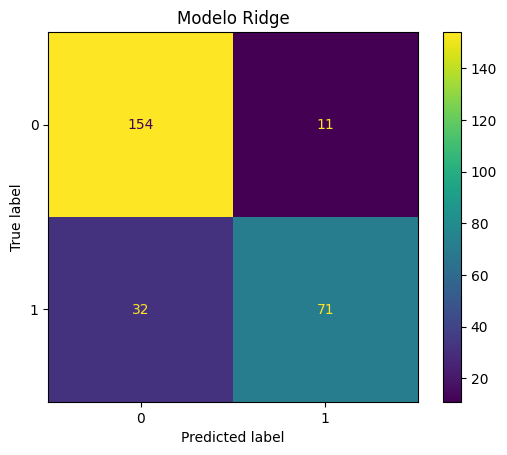

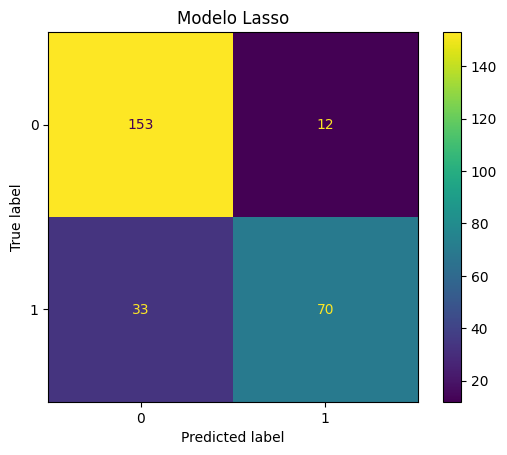

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
#Visualizar con una gráfica la matriz de confusión (Ridge)
ConfusionMatrixDisplay.from_estimator( logistic_ridge, X_transf_test, y_test)
plt.title("Modelo Ridge")
plt.show()
#Visualizar con una gráfica la matriz de confusión (Lasso)
ConfusionMatrixDisplay.from_estimator( logistic_lasso, X_transf_test, y_test)
plt.title("Modelo Lasso")
plt.show()

Cálculo de la sensitividad y especificidad:

In [82]:
#Extraigo de la matriz los elementos requeridos
TP = matriz_confusion_ridge[1][1]
TN = matriz_confusion_ridge[0][0]
FP = matriz_confusion_ridge[0][1]
FN = matriz_confusion_ridge[1][0]

# Sensitividad
conf_sensitivity = (TP / float(TP + FN))
print("La sensitividad es (Ridge): %.3f " % conf_sensitivity)

# Especificidad
conf_specificity = (TN / float(TN + FP))
print("La especificidad es (Ridge): %.3f " % conf_specificity)

La sensitividad es (Ridge): 0.689 
La especificidad es (Ridge): 0.933 


In [83]:
#Extraigo de la matriz los elementos requeridos
TP = matriz_confusion_lasso[1][1]
TN = matriz_confusion_lasso[0][0]
FP = matriz_confusion_lasso[0][1]
FN = matriz_confusion_lasso[1][0]

# Sensitividad
conf_sensitivity = (TP / float(TP + FN))
print("La sensitividad es (Lasso): %.3f " % conf_sensitivity)

# Especificidad
conf_specificity = (TN / float(TN + FP))
print("La especificidad es (Lasso): %.3f " % conf_specificity)

La sensitividad es (Lasso): 0.680 
La especificidad es (Lasso): 0.927 


Calculamos las probabilidades para computar la curva ROC:



In [84]:
#Modelo Ridge
#Hay que generar las probabilidades predichas
prob_predictions_ridge = logistic_ridge.predict_proba(X_transf_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)

#Extraemos las probabilidades de éxito
prob_predictions_success_ridge  = prob_predictions_ridge[:,1]

np.set_printoptions(suppress=True) #Suprimir notación científica
print("Probabilidades predichas para éxito (y=1) el conjunto de prueba (Ridge):")
print(np.round(prob_predictions_success_ridge,4))

Probabilidades predichas para éxito (y=1) el conjunto de prueba (Ridge):
[0.0906 0.6225 0.0343 0.9731 0.0916 0.9459 0.0343 0.1111 0.9537 0.9748
 0.0079 0.0549 0.2986 0.2225 0.6634 0.0824 0.9836 0.0934 0.0577 0.2084
 0.9362 0.0749 0.0921 0.2261 0.5214 0.2084 0.1206 0.6425 0.247  0.9319
 0.0605 0.6744 0.0841 0.0872 0.1207 0.1014 0.0477 0.1074 0.0437 0.0803
 0.0605 0.8673 0.5835 0.0684 0.85   0.205  0.2648 0.0324 0.1352 0.0763
 0.4589 0.0864 0.0721 0.0568 0.2538 0.4571 0.3806 0.6612 0.9649 0.3894
 0.084  0.9529 0.7126 0.3481 0.6809 0.0778 0.1505 0.7311 0.1668 0.4718
 0.0768 0.0855 0.0856 0.0749 0.1854 0.249  0.6734 0.0273 0.531  0.6726
 0.3452 0.876  0.3774 0.8051 0.5129 0.0748 0.107  0.7021 0.6029 0.093
 0.8464 0.6285 0.8272 0.5175 0.2449 0.0206 0.205  0.045  0.2904 0.7519
 0.8086 0.1139 0.6725 0.2865 0.0473 0.0721 0.195  0.0793 0.5912 0.7778
 0.0623 0.0845 0.3167 0.7346 0.4792 0.1037 0.2575 0.4523 0.2587 0.0978
 0.4812 0.0732 0.3592 0.7325 0.1917 0.9786 0.0487 0.0891 0.066  0.6224
 0.09

In [85]:
#Modelo Lasso
#Hay que generar las probabilidades predichas
prob_predictions_lasso = logistic_lasso.predict_proba(X_transf_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)

#Extraemos las probabilidades de éxito
prob_predictions_success_lasso  = prob_predictions_lasso[:,1]

np.set_printoptions(suppress=True) #Suprimir notación científica
print("Probabilidades predichas para éxito (y=1) el conjunto de prueba (Lasso):")
print(np.round(prob_predictions_success_lasso,4))

Probabilidades predichas para éxito (y=1) el conjunto de prueba (Lasso):
[0.0913 0.6487 0.0402 0.9667 0.0933 0.9394 0.0402 0.1224 0.9458 0.9696
 0.0092 0.062  0.3319 0.2195 0.6686 0.0872 0.9747 0.1246 0.0645 0.2077
 0.9397 0.0805 0.0984 0.2226 0.5225 0.2077 0.1311 0.6527 0.283  0.9135
 0.0672 0.7146 0.0888 0.0915 0.1395 0.1381 0.055  0.1068 0.0512 0.0853
 0.0672 0.8527 0.5696 0.0747 0.8371 0.2289 0.2979 0.0439 0.1442 0.0817
 0.4862 0.0877 0.078  0.0638 0.2421 0.436  0.4108 0.6523 0.9497 0.3827
 0.0856 0.9431 0.7002 0.3487 0.6802 0.0803 0.1578 0.7482 0.1714 0.4623
 0.0823 0.09   0.0901 0.0805 0.1881 0.2866 0.659  0.0337 0.5397 0.6626
 0.3417 0.8608 0.3933 0.785  0.5364 0.0804 0.1166 0.6773 0.6131 0.0967
 0.8267 0.6335 0.8216 0.5522 0.2976 0.0244 0.2048 0.0512 0.283  0.7137
 0.8055 0.1189 0.6625 0.3001 0.0546 0.078  0.1963 0.0845 0.5913 0.7825
 0.0665 0.0873 0.3349 0.7102 0.4671 0.0895 0.2777 0.4302 0.2712 0.0987
 0.455  0.0811 0.3673 0.7218 0.1935 0.9767 0.0561 0.0932 0.0708 0.6289
 0.0

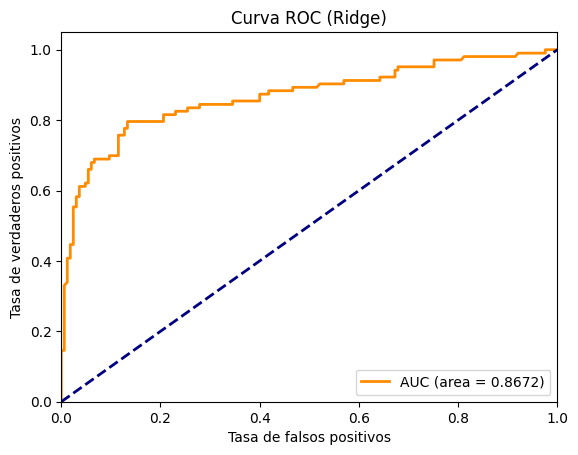

In [86]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, prob_predictions_success_ridge )
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC e indicar AUC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUC (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC (Ridge)')
plt.legend(loc="lower right")
plt.show()

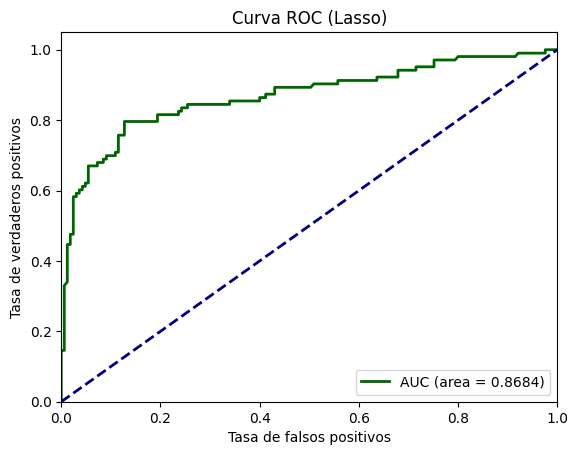

In [87]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, prob_predictions_success_lasso )
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC e indicar AUC
plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2, label='AUC (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC (Lasso)')
plt.legend(loc="lower right")
plt.show()

## Métricas en el caso de clases desbalanceadas

En caso de presentarse un **desequilibrio de clases**, se recomienda calcular la **precisión** y la **curva Precisión-Recuperación** --> Presición-Recall curve y el coeficiente de correlación de Matthews

In [88]:
from sklearn.metrics import precision_score

print("La precisión en los datos de prueba en el modelo Ridge es: %.4f"
      % precision_score(y_test, predictions_ridge))

print("La precisión en los datos de prueba en el modelo Lasso es: %.4f"
      % precision_score(y_test, predictions_lasso))

La precisión en los datos de prueba en el modelo Ridge es: 0.8659
La precisión en los datos de prueba en el modelo Lasso es: 0.8537


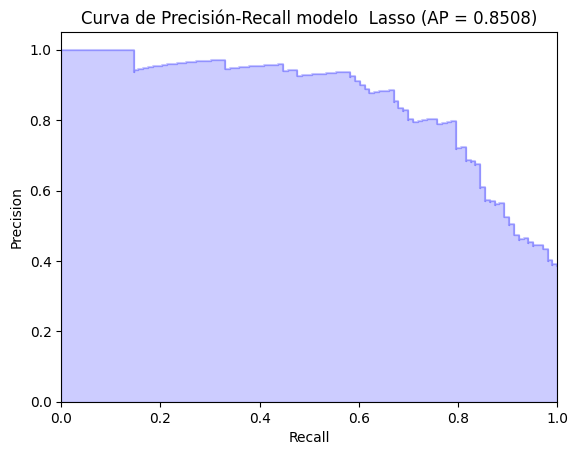

In [89]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Calcular la curva de Precisión-Recall
precision, recall, _ = precision_recall_curve(y_test, prob_predictions_success_lasso)

# Calcular el área bajo la curva de Precisión-Recall
average_precision = average_precision_score(y_test, prob_predictions_success_lasso)

# Graficar la curva de Precisión-Recall
plt.figure()
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Curva de Precisión-Recall modelo  Lasso (AP = {0:0.4f})'.format(average_precision))
plt.show()

In [90]:
from sklearn.metrics import matthews_corrcoef

# Calcular el Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, predictions_lasso)

print("Coefficiente de correlación de Matthews (Lasso): %.4f" % mcc)

Coefficiente de correlación de Matthews (Lasso): 0.6406


## Ajuste de lambda con validación cruzada

Para encontrar el **valor de lambda** que mejor ajusta los modelos se procede a aplicar el procedimiento de validación cruzada.

### Modelo Ridge con CV

In [96]:
from sklearn.linear_model import LogisticRegressionCV

logistic_ridge_cv = LogisticRegressionCV(Cs=100, penalty='l2',cv=5, random_state=0)

logistic_ridge_cv.fit(X_transf_train, y_train)

LogisticRegressionCV(Cs=100, cv=5, random_state=0)

In [97]:
# Obtener el mejor valor del hiperparámetro C
best_C_ridge = logistic_ridge_cv.C_[0]
print("Mejor valor de C: %0.3f" % best_C_ridge)

# El valor de lambda será el inverso de C
best_lambda_ridge = 1 / best_C_ridge

print("Mejor valor de lambda: %0.3f" % best_lambda_ridge)

Mejor valor de C: 0.056
Mejor valor de lambda: 17.886


Una vez obtenido el mejor valor de lambda (en este caso C = 1/lambda) se procede a ajustar el modelo con este valor.

In [98]:
#Se instancia el objeto (penalty='l2' corresponde a Ridge)
# con el mejor valor de C
logistic_ridge_best_C  = LogisticRegression(penalty='l2', random_state=0,
                                    C=best_C_ridge )

#Se hace el ajuste
logistic_ridge_best_C.fit(X_transf_train, y_train)

LogisticRegression(C=np.float64(0.055908101825122285), random_state=0)

In [99]:
# Extraer los coefficientes del mejor ajuste
coef_ridge_best_C = logistic_ridge_best_C.coef_[0,0:16]
#Mostralos en un pandas series
print("Variable y coeficiente:")
pd.Series(coef_ridge_best_C ,
          index = X_transf_train.columns )

Variable y coeficiente:


,0
Pclass,0.597338
Age,-0.180288
SibSp,-0.479997
Parch,-0.153794
Fare,0.291393
Companions,-0.028379
Sex_male,-0.396431
Sex_female,0.396431
Title_Mr,-0.381742
Title_Mrs,0.252565


### Modelo Lasso con CV

In [100]:
from sklearn.linear_model import LogisticRegressionCV

logistic_lasso_cv = LogisticRegressionCV(Cs=100, penalty='l1',
                                         cv=5, random_state=0,
                                         solver='saga')

logistic_lasso_cv.fit(X_transf_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegressionCV(Cs=100, cv=5, penalty='l1', random_state=0, solver='saga')

In [101]:
# Obtener el mejor valor del hiperparámetro C
best_C_lasso = logistic_lasso_cv.C_[0]
print("Mejor valor de C: %0.3f" % best_C_lasso)

# El valor de lambda será el inverso de C
best_lambda_lasso = 1 / best_C_lasso

print("Mejor valor de lambda: %0.3f" % best_lambda_lasso)

Mejor valor de C: 0.298
Mejor valor de lambda: 3.352


In [102]:
#Se instancia el objeto (penalty='l1' corresponde a lasso)
# con el mejor valor de C
logistic_lasso_best_C  = LogisticRegression(penalty='l1',
                                            random_state=0,
                                            solver='saga',
                                            C=best_C_lasso )

#Se hace el ajuste
logistic_lasso_best_C.fit(X_transf_train, y_train)

LogisticRegression(C=np.float64(0.298364724028334), penalty='l1',
                   random_state=0, solver='saga')

In [103]:
# Extraer los coefficientes del mejor ajuste
coef_lasso_best_C = logistic_lasso_best_C.coef_[0,0:16]
#Mostralos en un pandas series
print("Variable y coeficiente:")
pd.Series(coef_lasso_best_C,
          index = X_transf_train.columns )

Variable y coeficiente:


,0
Pclass,0.765862
Age,-0.220248
SibSp,-0.644983
Parch,-0.153914
Fare,0.250088
Companions,0.000000
Sex_male,-0.675645
Sex_female,0.675645
Title_Mr,0.000000
Title_Mrs,0.187110


Para comparar la exactitud de los dos modelos primero se hacen las predicciones en el conjunto de prueba

In [104]:
#Hay que generar las predicciones (0 o 1) en un numpy array
predictions_ridge_best_C = logistic_ridge_best_C.predict(X_transf_test)

In [105]:
#Hay que generar las predicciones (0 o 1) en un numpy array
predictions_lasso_best_C = logistic_lasso_best_C.predict(X_transf_test)

In [106]:
print("La exactitud en los datos de prueba en el modelo Ridge es: %.4f"
      % accuracy_score(y_test, predictions_ridge_best_C))

print("La exactitud en los datos de prueba en el modelo Lasso es: %.4f"
      % accuracy_score(y_test, predictions_lasso_best_C))

La exactitud en los datos de prueba en el modelo Ridge es: 0.8284
La exactitud en los datos de prueba en el modelo Lasso es: 0.8284


Calculamos el área bajo la curva, como métrica que resume el poder de clasificación de ambos modelos. Para tal fin, necesitamos calcular las probabilidades:




In [107]:
#Modelo Ridge
#Hay que generar las probabilidades predichas
prob_predictions_ridge_best_C = logistic_ridge_best_C.predict_proba(X_transf_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)

#Extraemos las probabilidades de éxito
prob_predictions_success_ridge_best_C  = prob_predictions_ridge_best_C[:,1]

#Modelo Lasso
#Hay que generar las probabilidades predichas
prob_predictions_lasso_best_C = logistic_lasso_best_C.predict_proba(X_transf_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)

#Extraemos las probabilidades de éxito
prob_predictions_success_lasso_best_C  = prob_predictions_lasso_best_C[:,1]

In [108]:
# Ridge:
fpr, tpr, thresholds = roc_curve(y_test, prob_predictions_success_ridge_best_C )
roc_auc_ridge_best_C = auc(fpr, tpr)

print("La AUC del modelo Ridge es: %.4f" % roc_auc_ridge_best_C)

#Lasso:
fpr, tpr, thresholds = roc_curve(y_test, prob_predictions_success_lasso_best_C )
roc_auc_lasso_best_C = auc(fpr, tpr)

print("La AUC del modelo Lasso es: %.4f" % roc_auc_lasso_best_C)

La AUC del modelo Ridge es: 0.8668
La AUC del modelo Lasso es: 0.8683


# Modelos de árboles de decisión

Se tiene que usar la clase `DecisionTreeClassifier` para ajustar un árbol de decisión para clasificación

In [109]:
from sklearn.tree import DecisionTreeClassifier

#Se inicializa el objeto
arbol_clasificacion = DecisionTreeClassifier(random_state=0, criterion='entropy')

#El ajuste se puede hacer en los datos sin transformación de centro y escala ()
arbol_clasificacion.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

Para medir la exactitud del modelo se calculan la predicciones:

In [111]:
#Predcciones de árbol de clasificación
y_pred_arbol_clasificacion = arbol_clasificacion.predict(X_test)

from sklearn.metrics import accuracy_score

print("La exactitud en los datos de prueba del árbol de clasificación: %.4f"
      % accuracy_score(y_test, y_pred_arbol_clasificacion))

La exactitud en los datos de prueba del árbol de clasificación: 0.8209


Se realiza el cálculo de la matriz de confusión

In [112]:
#Se importa la función para calcular la matriz de confusión
from sklearn.metrics import confusion_matrix

#Cálculo de la matriz de confusión (Ridge)
matriz_confusion_arbol_clasificacion = confusion_matrix(y_test, y_pred_arbol_clasificacion)
print("Matriz de confusión (Árbol de clasificación):")
print(matriz_confusion_arbol_clasificacion )

Matriz de confusión (Árbol de clasificación):
[[141  24]
 [ 24  79]]


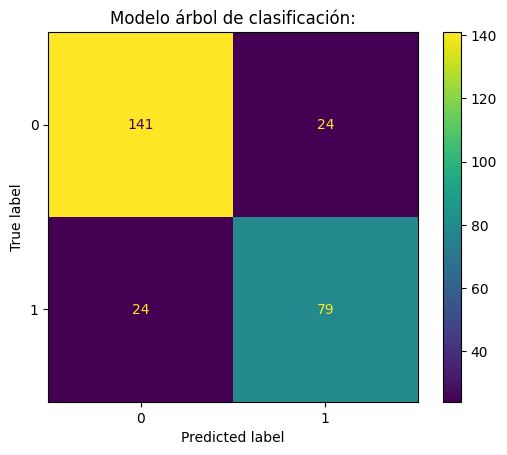

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay
#Visualizar con una gráfica la matriz de confusión
ConfusionMatrixDisplay.from_estimator( arbol_clasificacion, X_test, y_test)
plt.title("Modelo árbol de clasificación:")
plt.show()

Se generan algunas métricas del desempeño del clasificador

In [114]:
#Extraigo de la matriz los elementos requeridos
TP = matriz_confusion_arbol_clasificacion[1][1]
TN = matriz_confusion_arbol_clasificacion[0][0]
FP = matriz_confusion_arbol_clasificacion[0][1]
FN = matriz_confusion_arbol_clasificacion[1][0]

# Sensitividad
conf_sensitivity = (TP / float(TP + FN))
print("La sensitividad es: %.3f " % conf_sensitivity)

# Especificidad
conf_specificity = (TN / float(TN + FP))
print("La especificidad es: %.3f " % conf_specificity)

La sensitividad es: 0.767 
La especificidad es: 0.855 


Es necesario calcular las probabilidades predichas para construir la curva ROC.

In [115]:
#Hay que generar las probabilidades predichas
y_pred_prob_arbol_clasificacion = arbol_clasificacion.predict_proba(X_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_arbol_clasificacion = y_pred_prob_arbol_clasificacion[:,1]

In [116]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_arbol_clasificacion)
roc_auc = auc(fpr, tpr)

print("El área bajo la curva es: %.3f " % roc_auc)

El área bajo la curva es: 0.813 


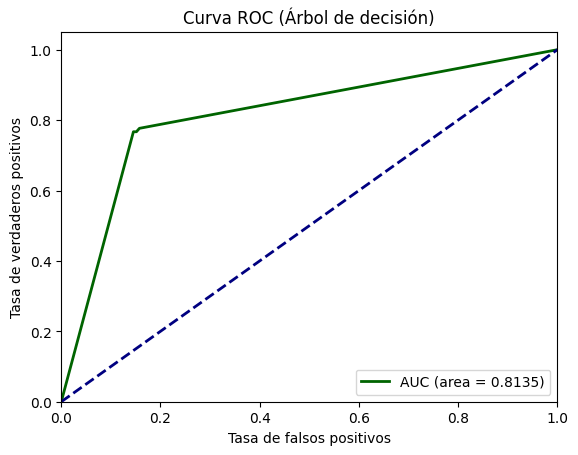

In [117]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_arbol_clasificacion)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC e indicar AUC
plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2, label='AUC (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC (Árbol de decisión)')
plt.legend(loc="lower right")
plt.show()

## Como buscar los mejores hiperparametros

### Busqueda por cuadricula

In [118]:
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de hiperparámetros que deseas explorar
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4] }

In [119]:
# Definir el clasificador de árbol de decisión
clasificador = DecisionTreeClassifier()

# Configurar la búsqueda de hiperparámetros con GridSearchCV y la validación cruzada
grid_search = GridSearchCV(estimator=clasificador, param_grid=param_grid, cv=5)

# Ejecutar la búsqueda de hiperparámetros en los datos de entrenamiento
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [120]:
# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Modelo con los mejores hiperparámetros
arbol_clasificacion_grid = grid_search.best_estimator_

Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [121]:
#Método score() para calcular la exactitud en los datos de prueba
exactitud = arbol_clasificacion_grid.score(X_test, y_test)
print("Exactitud del modelo con búsqueda de cuadrícula: %.4f" % exactitud)

Exactitud del modelo con búsqueda de cuadrícula: 0.8321


Se calculan las probabilidades para generar la correspondiente curva ROC y área bajo la curva:

In [122]:
#Hay que generar las probabilidades predichas
y_pred_prob_arbol_clasificacion_grid = arbol_clasificacion_grid.predict_proba(X_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_arbol_clasificacion_grid = y_pred_prob_arbol_clasificacion_grid[:,1]

In [123]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_arbol_clasificacion_grid)
roc_auc = auc(fpr, tpr)

print("AUC del modelo con búsqueda de cuadrícula: %.4f" % roc_auc)

AUC del modelo con búsqueda de cuadrícula: 0.8536


### Optimización bayesiana

Para implementar la optimización bayesiana de los parámetros es necesario usar el paquete `scikit-optimize` también llamando `skopt`. Por tal motivo, se instala primero.

In [124]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.2 MB/s eta 0:00:00


In [125]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Definir el espacio de búsqueda de hiperparámetros
param_space = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(1, 20),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5) }

In [126]:
# Configurar la búsqueda de hiperparámetros con BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=clasificador,
    search_spaces=param_space,
    n_iter=50,  # Número total de evaluaciones del modelo
    cv=5,  # Número de divisiones de la validación cruzada
    random_state=42  )

# Ejecutar la búsqueda de hiperparámetros en los datos de entrenamiento
bayes_search.fit(X_train, y_train)

BayesSearchCV(cv=5, estimator=DecisionTreeClassifier(), random_state=42,
              search_spaces={'criterion': Categorical(categories=('gini', 'entropy'), prior=None),
                             'max_depth': Integer(low=1, high=20, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=1, high=5, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=2, high=10, prior='uniform', transform='normalize')})

In [127]:
# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(bayes_search.best_params_)

Mejores hiperparámetros encontrados:
OrderedDict({'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 3})


In [128]:
# Evaluar el rendimiento del modelo con los
# mejores hiperparámetros en los datos de prueba
arbol_clasificacion_bayes = bayes_search.best_estimator_

exactitud = arbol_clasificacion_bayes.score(X_test, y_test)
print("Exactitud del modelo con optimización bayesiana: %.4f" % exactitud )

Exactitud del modelo con optimización bayesiana: 0.8321


In [129]:
#Hay que generar las probabilidades predichas
y_pred_prob_arbol_clasificacion_bayes = arbol_clasificacion_bayes.predict_proba(X_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_arbol_clasificacion_bayes = y_pred_prob_arbol_clasificacion_bayes[:,1]

In [130]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_arbol_clasificacion_bayes)
roc_auc = auc(fpr, tpr)

print("AUC del modelo con Bayes: %.4f" % roc_auc)

AUC del modelo con Bayes: 0.8518


### Metricas de opt para el mejor modelo

De acuerdo al análisis anterior, el mejor modelo se consigue con el método de gridSearch(). Por tal motivo, se usan esos hiperparémetros para el modelo final.

In [131]:
# Se toma el árbol de grid search como el mejor:
arbol_clasificacion_optimo = grid_search.best_estimator_

#Se ajusta la combinación de los mejores hiperparámetros en los datos de entrenamiento
arbol_clasificacion_optimo.fit(X_train, y_train)

#Predcciones de árbol de clasificación
y_pred_arbol_clasificacion_optimo = arbol_clasificacion_optimo.predict(X_test)

Se realiza el cálculo de la **matriz de confusión**

In [132]:
#Se importa la función para calcular la matriz de confusión
from sklearn.metrics import confusion_matrix

#Cálculo de la matriz de confusión (Ridge)
matriz_confusion_arbol_clasificacion_optimo = confusion_matrix(y_test, y_pred_arbol_clasificacion_optimo)
print("Matriz de confusión (Árbol de clasificación óptimo):")
print(matriz_confusion_arbol_clasificacion_optimo )

Matriz de confusión (Árbol de clasificación óptimo):
[[145  20]
 [ 25  78]]


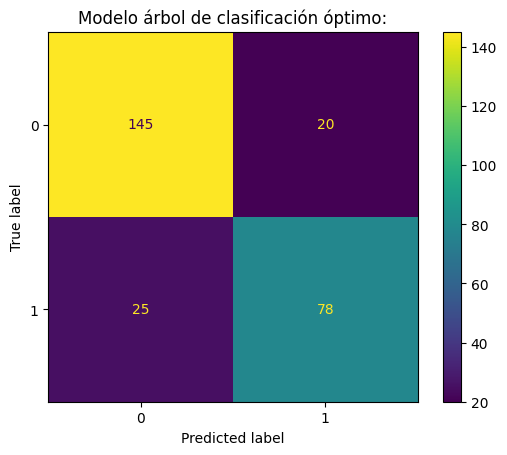

In [133]:
from sklearn.metrics import ConfusionMatrixDisplay
#Visualizar con una gráfica la matriz de confusión
ConfusionMatrixDisplay.from_estimator( arbol_clasificacion_optimo,
                                      X_test, y_test)
plt.title("Modelo árbol de clasificación óptimo:")
plt.show()

Se generan algunas métricas del desempeño del clasificador




In [134]:
#Extraigo de la matriz los elementos requeridos
TP = matriz_confusion_arbol_clasificacion_optimo[1][1]
TN = matriz_confusion_arbol_clasificacion_optimo[0][0]
FP = matriz_confusion_arbol_clasificacion_optimo[0][1]
FN = matriz_confusion_arbol_clasificacion_optimo[1][0]

# Sensitividad
conf_sensitivity = (TP / float(TP + FN))
print("La sensitividad es: %.3f " % conf_sensitivity)

# Especificidad
conf_specificity = (TN / float(TN + FP))
print("La especificidad es: %.3f " % conf_specificity)

La sensitividad es: 0.757 
La especificidad es: 0.879 


Es necesario calcular las probabilidades predichas para construir la curva ROC.

In [135]:
#Hay que generar las probabilidades predichas
y_pred_prob_arbol_clasificacion_optimo = arbol_clasificacion_optimo.predict_proba(X_test)

#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_arbol_clasificacion_optimo = y_pred_prob_arbol_clasificacion_optimo[:,1]

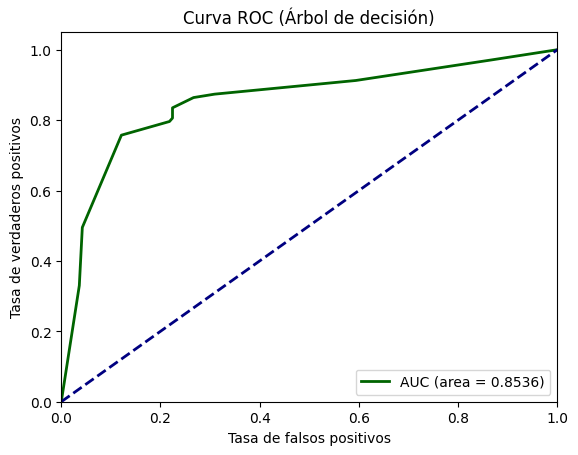

In [136]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test,
                      y_pred_prob_exito_arbol_clasificacion_optimo)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC e indicar AUC
plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2,
         label='AUC (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC (Árbol de decisión)')
plt.legend(loc="lower right")
plt.show()

Se puede graficar el árbol de clásficación que arroja los mejores resultados:

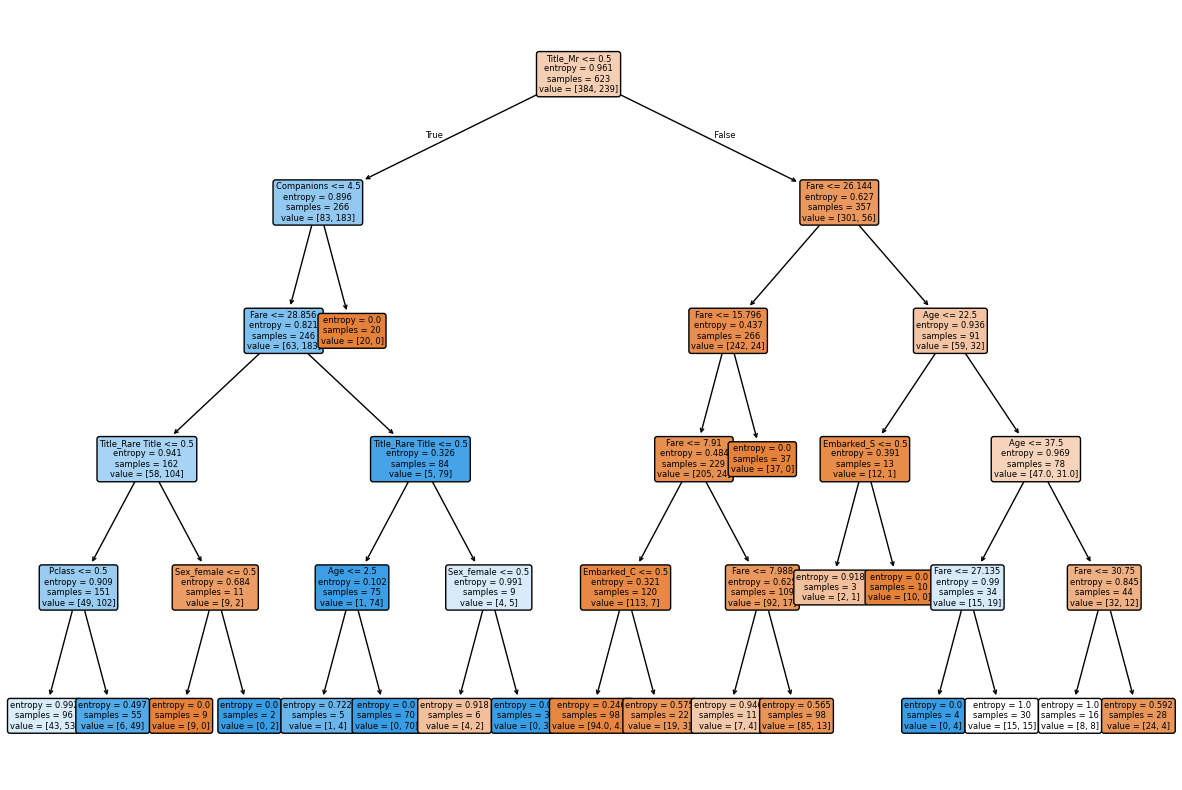

In [137]:
from sklearn.tree import  plot_tree
import matplotlib.pyplot as plt
# Graficar el árbol de decisión
plt.figure(figsize=(15, 10))
plot_tree(arbol_clasificacion_optimo, filled=True,feature_names=X_train.columns, rounded=True, fontsize=6)
plt.show()

## Modelo de bosques aleatorios

Se tiene que usar la clase `RandomForestClassifier` para ajustar un árbol de decisión para clasificación

In [138]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar el objeto Bosques Aleatorios
class_rf = RandomForestClassifier(n_estimators=200, random_state=42)

#El ajuste se puede hacer en los datos sin transformación de centro y escala ()
class_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [139]:
# Evaluar la exactitud del modelo
exactitud = class_rf.score(X_test, y_test)
print("Exactitud del modelo de Bosques Aleatorios: %.4f" % exactitud)

Exactitud del modelo de Bosques Aleatorios: 0.8134


Es necesario calcular las probabilidades predichas para construir la curva ROC.

In [140]:
#Hay que generar las probabilidades predichas
y_pred_prob_class_rf = class_rf.predict_proba(X_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_class_rf = y_pred_prob_class_rf[:,1]

In [141]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_class_rf)
roc_auc = auc(fpr, tpr)
print("AUC del modelo inicial de bosques aleatorios: %.4f" % roc_auc)

AUC del modelo inicial de bosques aleatorios: 0.8648


### Busqueda de hiperparametros

#### Busqueda aleatoria

In [142]:
# Definir la cuadrícula de hiperparámetros que deseas explorar
param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Inicializar el clasificador de Bosque Aleatorio
rf = RandomForestClassifier(random_state=10)

In [143]:
from sklearn.model_selection import RandomizedSearchCV

# Configurar la búsqueda de hiperparámetros con RandomizedSearchCV
class_rf_random = RandomizedSearchCV(estimator=rf,
                                   param_distributions=param_dist,
                                   n_iter=100,
                                   cv=5,
                                   random_state=42,
                                   n_jobs=-1)

# Ejecutar la búsqueda de hiperparámetros en los datos de entrenamiento
class_rf_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=10),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 150, 200, 250]},
                   random_state=42)

Se pueden visualizar los resultados de las corridas a partir del atributo cv_results. Es conveniente pasarlo a un pandas Dataframe

In [144]:
#El atributo cv_results_ es un diccionario que se pasa a dataframe
df_results_class_rf_random = pd.DataFrame(class_rf_random.cv_results_)

#Nombre de las columnas
print(df_results_class_rf_random.columns)

df_results_class_rf_random.head()

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_n_estimators', 'param_min_samples_split',
       'param_min_samples_leaf', 'param_max_features', 'param_max_depth',
       'params', 'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.769478,0.208890,0.035036,0.017615,150,10,2,log2,20,"{'n_estimators': 150, 'min_samples_split': 10,...",0.808,0.856,0.800,0.814516,0.870968,0.829897,0.028207,32
1,0.508240,0.067248,0.021779,0.007122,150,10,5,log2,20,"{'n_estimators': 150, 'min_samples_split': 10,...",0.800,0.832,0.824,0.814516,0.862903,0.826684,0.021011,53
2,0.630058,0.122949,0.052384,0.002673,200,5,5,log2,10,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.792,0.840,0.808,0.806452,0.846774,0.818645,0.021068,98
3,0.439296,0.093951,0.027633,0.011900,150,10,5,sqrt,20,"{'n_estimators': 150, 'min_samples_split': 10,...",0.800,0.832,0.824,0.814516,0.862903,0.826684,0.021011,53
4,0.755030,0.140739,0.045539,0.017015,250,2,2,sqrt,None,"{'n_estimators': 250, 'min_samples_split': 2, ...",0.800,0.864,0.800,0.830645,0.870968,0.833123,0.030285,15


In [145]:
# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(class_rf_random.best_params_)

Mejores hiperparámetros encontrados:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


In [146]:
# Evaluar el rendimiento del modelo con los mejores hiperparámetros en los datos de prueba
exactitud = class_rf_random.best_estimator_.score(X_test, y_test)
print("Exactitud del mejor modelo (random search): %.4f" % exactitud)

Exactitud del mejor modelo (random search): 0.8284


In [147]:
#Hay que generar las probabilidades predichas
y_pred_prob_class_rf_random = class_rf_random.predict_proba(X_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_class_rf_random = y_pred_prob_class_rf_random[:,1]

In [148]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_class_rf_random)
roc_auc = auc(fpr, tpr)
print("AUC modelo de Bosques aleatorios con búsqueda aleatoria: %.4f" % roc_auc)

AUC modelo de Bosques aleatorios con búsqueda aleatoria: 0.8698


#### Optimizacion bayesiana

In [149]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Definir el espacio de búsqueda de hiperparámetros

param_dist = {
    'n_estimators': Integer(100,250),
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': Categorical(['sqrt', 'log2']) }

In [150]:
# Configurar la búsqueda de hiperparámetros con BayesSearchCV
rf_bayes = BayesSearchCV(
    estimator=rf,
    search_spaces=param_dist,
    n_iter=50,  # Número total de evaluaciones del modelo
    cv=5,  # Número de divisiones de la validación cruzada
    random_state=42  )

# Ejecutar la búsqueda de hiperparámetros en los datos de entrenamiento
rf_bayes.fit(X_train, y_train)

BayesSearchCV(cv=5, estimator=RandomForestClassifier(random_state=10),
              random_state=42,
              search_spaces={'max_depth': [None, 10, 20],
                             'max_features': Categorical(categories=('sqrt', 'log2'), prior=None),
                             'min_samples_leaf': [1, 2, 5],
                             'min_samples_split': [2, 5, 10],
                             'n_estimators': Integer(low=100, high=250, prior='uniform', transform='normalize')})

In [151]:
# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(rf_bayes.best_params_)

Mejores hiperparámetros encontrados:
OrderedDict({'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 189})


In [152]:
# Evaluar el rendimiento del modelo con los
# mejores hiperparámetros en los datos de prueba
rf_bayes_optimo = rf_bayes.best_estimator_

exactitud= rf_bayes_optimo.score(X_test, y_test)
print("Exactitud del modelo con optimización bayesiana: %.4f" % exactitud )

Exactitud del modelo con optimización bayesiana: 0.8433


In [153]:
#Hay que generar las probabilidades predichas
y_pred_prob_rf_bayes_optimo = rf_bayes_optimo.predict_proba(X_test)
#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_rf_bayes_optimo = y_pred_prob_rf_bayes_optimo[:,1]

In [154]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_exito_rf_bayes_optimo)
roc_auc = auc(fpr, tpr)

print("AUC del modelo de bosques aleatorios con optimización Bayesiana: %.4f" % roc_auc)

AUC del modelo de bosques aleatorios con optimización Bayesiana: 0.8688


### Métricas de clasificación para el mejor modelo


De acuerdo a los resultados anteriores, el mejor modelo se consigue con el método de RandomSearch (mejor exactitud y marginalmente mejor AUC ROC). Por tal motivo, se usan esos hiperparémetros para el modelo final.

In [155]:
# Se toma el árbol de grid search como el mejor:
class_rf_optimo = class_rf_random.best_estimator_

#Se ajusta en todos los datos de entrenamiento
class_rf_optimo.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', min_samples_split=5,
                       random_state=10)

In [156]:
#Se importa la función para calcular la matriz de confusión
from sklearn.metrics import confusion_matrix

#Predcciones de árbol de clasificación
y_pred_class_rf_optimo = class_rf_optimo.predict(X_test)

#Cálculo de la matriz de confusión (Ridge)
matriz_confusion_class_rf_optimo = confusion_matrix(y_test, y_pred_class_rf_optimo )
print("Matriz de confusión (Bosque aleatorio óptimo):")
print(matriz_confusion_class_rf_optimo)

Matriz de confusión (Bosque aleatorio óptimo):
[[153  12]
 [ 34  69]]


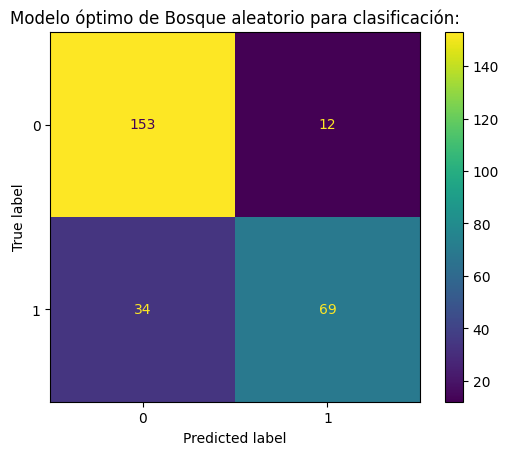

In [157]:
from sklearn.metrics import ConfusionMatrixDisplay
#Visualizar con una gráfica la matriz de confusión
ConfusionMatrixDisplay.from_estimator( class_rf_optimo,
                                      X_test, y_test)
plt.title("Modelo óptimo de Bosque aleatorio para clasificación:")
plt.show()

In [158]:
#Extraigo de la matriz los elementos requeridos
TP = matriz_confusion_class_rf_optimo[1][1]
TN = matriz_confusion_class_rf_optimo[0][0]
FP = matriz_confusion_class_rf_optimo[0][1]
FN = matriz_confusion_class_rf_optimo[1][0]

# Sensitividad
conf_sensitivity = (TP / float(TP + FN))
print("La sensitividad es: %.3f " % conf_sensitivity)

# Especificidad
conf_specificity = (TN / float(TN + FP))
print("La especificidad es: %.3f " % conf_specificity)

La sensitividad es: 0.670 
La especificidad es: 0.927 


In [159]:
#Hay que generar las probabilidades predichas
y_pred_prob_class_rf_optimo = class_rf_optimo.predict_proba(X_test)

#Se tiene un array con dos columnas (1a --> prob fracaso, 2d --> prob éxito)
#Extraemos las probabilidades de éxito
y_pred_prob_exito_class_rf_optimo = y_pred_prob_class_rf_optimo[:,1]

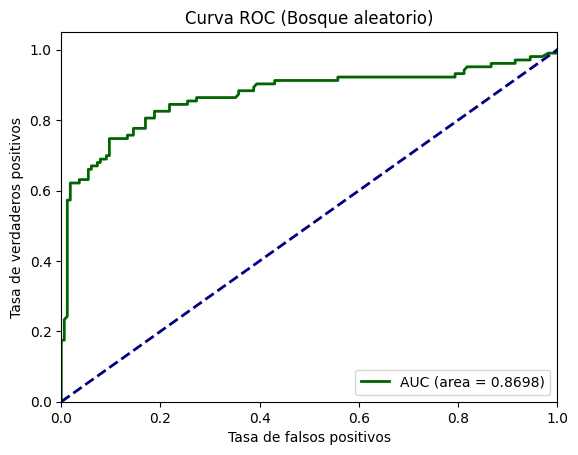

In [160]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC y Área bajo la curva ROC
fpr, tpr, thresholds = roc_curve(y_test,
                      y_pred_prob_exito_class_rf_optimo)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC e indicar AUC
plt.figure()
plt.plot(fpr, tpr, color='darkgreen', lw=2,
         label='AUC (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC (Bosque aleatorio)')
plt.legend(loc="lower right")
plt.show()